#5장. 토큰화

###5.1 단어 토큰화

In [1]:
review = "현실과 구분 불가능한 cg. 시각적 즐거움은 최고! 더불어 ost는 더더욱 최고!!"
tokenized = review.split()
print(tokenized)

['현실과', '구분', '불가능한', 'cg.', '시각적', '즐거움은', '최고!', '더불어', 'ost는', '더더욱', '최고!!']


###5.2 글자 토큰화

In [2]:
review = "현실과 구분 불가능한 cg. 시각적 즐거움은 최고! 더불어 ost는 더더욱 최고!!"
tokenized = list(review)
print(tokenized)

['현', '실', '과', ' ', '구', '분', ' ', '불', '가', '능', '한', ' ', 'c', 'g', '.', ' ', '시', '각', '적', ' ', '즐', '거', '움', '은', ' ', '최', '고', '!', ' ', '더', '불', '어', ' ', 'o', 's', 't', '는', ' ', '더', '더', '욱', ' ', '최', '고', '!', '!']


**자모 변환 함수**

In [3]:
!pip install jamo



```
retval = jamo.h2j(
    hangul_string
)
```
자모 변환 함수는 입력된 한글 문자열을 유니코드 U+1100~U+11FE 사이의 조합형 한글 자모로 변환하는 함수
* 조합형 : 글자를 자모 단위로 나눠 인코딩한 뒤 이를 조합해 한글을 표현
* 완성형: 조합된 글자 자체에 값을 부여해 인코딩하는 방식

한글 호환성 자모 변환 함수


```
retval = jamo.j2hcj(
  jamo
)
```
* h2j: 완성형으로 입력된 한글을 조합형 한글로 변환
* j2hcj: 조합형 한글 문자열을 자소 단위로 나눠 반환. 조합형 한글로 입력된 문자열은 초성, 중성, 종성으로 나뉨

* 개별 토큰은 아무런 의미X => 자연어 모델이 각 토큰의 의미를 조합해 결과 도출
-> 토큰 조합 방식을 사용해 문장 생성이나 개체명 인식 등을 구현할 경우, 다의어나 동음이의어가 많은 도메인에서 구별하는 것이 어려울 수 있음. 또 모델 입력 시퀀스의 길이가 길어질수록 연산량 증가한다는 단점 존재


In [4]:
from jamo import h2j, j2hcj
review = "현실과 구분 불가능한 cg. 시각적 즐거움은 최고! 더불어 ost는 더더욱 최고!!"
decomposed = j2hcj(h2j(review))
tokenized = list(decomposed)
print(tokenized)

['ㅎ', 'ㅕ', 'ㄴ', 'ㅅ', 'ㅣ', 'ㄹ', 'ㄱ', 'ㅘ', ' ', 'ㄱ', 'ㅜ', 'ㅂ', 'ㅜ', 'ㄴ', ' ', 'ㅂ', 'ㅜ', 'ㄹ', 'ㄱ', 'ㅏ', 'ㄴ', 'ㅡ', 'ㅇ', 'ㅎ', 'ㅏ', 'ㄴ', ' ', 'c', 'g', '.', ' ', 'ㅅ', 'ㅣ', 'ㄱ', 'ㅏ', 'ㄱ', 'ㅈ', 'ㅓ', 'ㄱ', ' ', 'ㅈ', 'ㅡ', 'ㄹ', 'ㄱ', 'ㅓ', 'ㅇ', 'ㅜ', 'ㅁ', 'ㅇ', 'ㅡ', 'ㄴ', ' ', 'ㅊ', 'ㅚ', 'ㄱ', 'ㅗ', '!', ' ', 'ㄷ', 'ㅓ', 'ㅂ', 'ㅜ', 'ㄹ', 'ㅇ', 'ㅓ', ' ', 'o', 's', 't', 'ㄴ', 'ㅡ', 'ㄴ', ' ', 'ㄷ', 'ㅓ', 'ㄷ', 'ㅓ', 'ㅇ', 'ㅜ', 'ㄱ', ' ', 'ㅊ', 'ㅚ', 'ㄱ', 'ㅗ', '!', '!']


###5.3 형태소 토큰화

**KoNLPy**
* 한국어 자연어 처리를 위해 개발된 라이브러리
* 명사 추출, 형태소 분석, 품사 태깅 등의 기능 제공
* 텍스트 마이닝, 감성 분석, 토픽 모델링 등 다양한 NLP 작업에 사용
* 자바 개발 키드 기반으로 개발됨
* Okt(Oopen Korean Text), 꼬꼬마(Kkma), Komoran, Hannanum, Mecab 등의 다양한 형태소 분석기 지원

In [5]:
!pip install konlpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.4/19.4 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.5/438.5 kB 48.4 MB/s eta 0:00:00


In [6]:
from konlpy.tag import Okt
okt = Okt()

sentence  ="무엇이든 상상할 수 있는 사람은 무엇이든 만들어 낼 수 있다."

nouns = okt.nouns(sentence)
phrases = okt.phrases(sentence)
morphs = okt.morphs(sentence)
pos = okt.pos(sentence)

print("명사 추출:", nouns)
print("구 추출:", phrases)
print("형태소 추출:", morphs)
print("품사 태깅:", pos)

명사 추출: ['무엇', '상상', '수', '사람', '무엇', '낼', '수']
구 추출: ['무엇', '상상', '상상할 수', '상상할 수 있는 사람', '사람']
형태소 추출: ['무엇', '이든', '상상', '할', '수', '있는', '사람', '은', '무엇', '이든', '만들어', '낼', '수', '있다', '.']
품사 태깅: [('무엇', 'Noun'), ('이든', 'Josa'), ('상상', 'Noun'), ('할', 'Verb'), ('수', 'Noun'), ('있는', 'Adjective'), ('사람', 'Noun'), ('은', 'Josa'), ('무엇', 'Noun'), ('이든', 'Josa'), ('만들어', 'Verb'), ('낼', 'Noun'), ('수', 'Noun'), ('있다', 'Adjective'), ('.', 'Punctuation')]


In [7]:
#Kkma #구문 추출 기능 지원X
from konlpy.tag import Kkma

kkma = Kkma()

sentence = "무엇이든 상상할 수 있는 사람은 무엇이든 만들어 낼 수 있다."

nouns = kkma.nouns(sentence)
sentences = kkma.sentences(sentence)
morphs = kkma.morphs(sentence)
pos = kkma.pos(sentence)

print("명사 추출:", nouns)
print("문장 추출:", sentences)
print("형태소 추출:", morphs)
print("품사 태깅:", pos)

명사 추출: ['무엇', '상상', '수', '사람', '무엇']
문장 추출: ['무엇이든 상상할 수 있는 사람은 무엇이든 만들어 낼 수 있다.']
형태소 추출: ['무엇', '이', '든', '상상', '하', 'ㄹ', '수', '있', '는', '사람', '은', '무엇', '이', '든', '만들', '어', '내', 'ㄹ', '수', '있', '다', '.']
품사 태깅: [('무엇', 'NNG'), ('이', 'VCP'), ('든', 'ECE'), ('상상', 'NNG'), ('하', 'XSV'), ('ㄹ', 'ETD'), ('수', 'NNB'), ('있', 'VV'), ('는', 'ETD'), ('사람', 'NNG'), ('은', 'JX'), ('무엇', 'NP'), ('이', 'VCP'), ('든', 'ECE'), ('만들', 'VV'), ('어', 'ECD'), ('내', 'VXV'), ('ㄹ', 'ETD'), ('수', 'NNB'), ('있', 'VV'), ('다', 'EFN'), ('.', 'SF')]


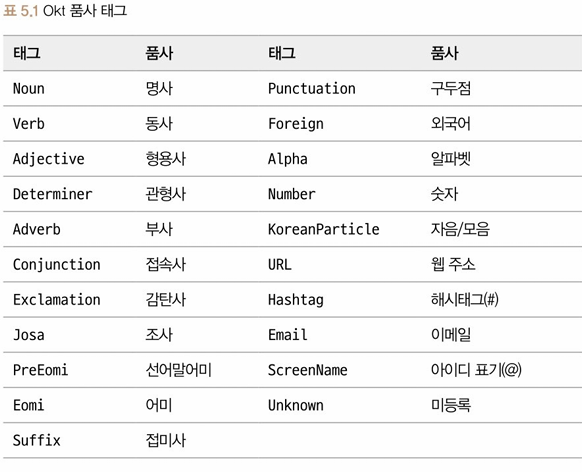

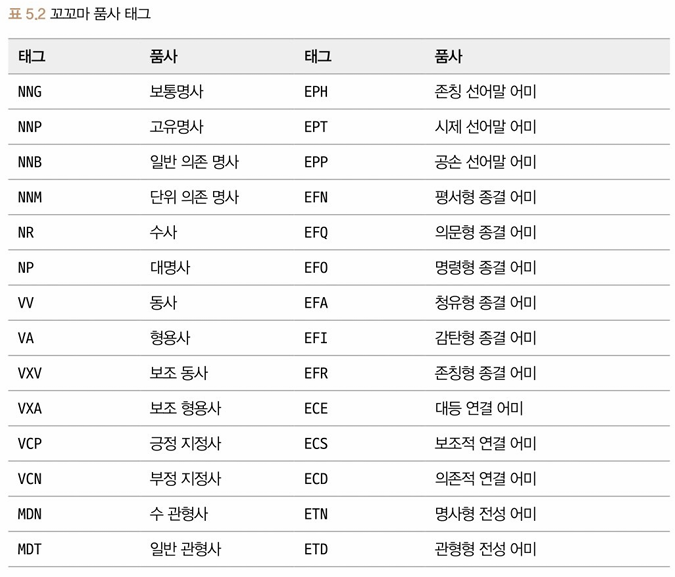

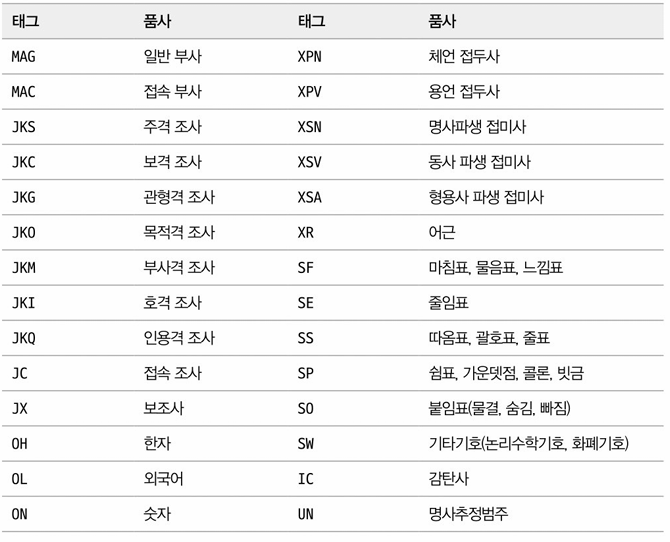

**NLTK**
* 토큰화, 형태소 분석, 구문 분석, 개체명 인식, 감성 분석 등과 같은 기능 제공

* 영어 자연어 처리 위해 개발. 다양한 언어도 가능
* Punkt 모델(통계 기반)과 Averaged Perceptron Tagger 모델(퍼셉트론 기반)을 활용해 작업 수행
=> 두 모델 모두 Treebank라는 대규모의 영어 말뭉치를 기반으로 학습


In [8]:
!pip install nltk

In [9]:
import nltk

nltk.download("punkt")
nltk.download("averaged_perceptron_tagger")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.


True

In [10]:
#영문 토큰화
from nltk import tokenize
import nltk

nltk.download("punkt_tab")

sentence = "Those who can imagine anything, can create the impossible."

word_tokens = tokenize.word_tokenize(sentence) #공백 기준으로 단어 분리
sent_tokens = tokenize.sent_tokenize(sentence) #문장을 입력받아 구두점을 기준으로 문장 분리해 리스트로 반환

print(word_tokens)
print(sent_tokens)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


['Those', 'who', 'can', 'imagine', 'anything', ',', 'can', 'create', 'the', 'impossible', '.']
['Those who can imagine anything, can create the impossible.']


In [11]:
from nltk import tag
from nltk import tokenize
import nltk

nltk.download('averaged_perceptron_tagger_eng')

sentence = "Those who can imagine anything, can create the impossible."

word_tokens = tokenize.word_tokenize(sentence)
pos = tag.pos_tag(word_tokens) #토큰화된 문장에서 품사 태깅을 수행

print(pos)

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


[('Those', 'DT'), ('who', 'WP'), ('can', 'MD'), ('imagine', 'VB'), ('anything', 'NN'), (',', ','), ('can', 'MD'), ('create', 'VB'), ('the', 'DT'), ('impossible', 'JJ'), ('.', '.')]


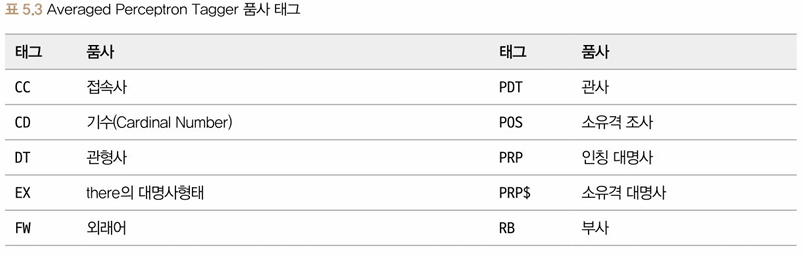

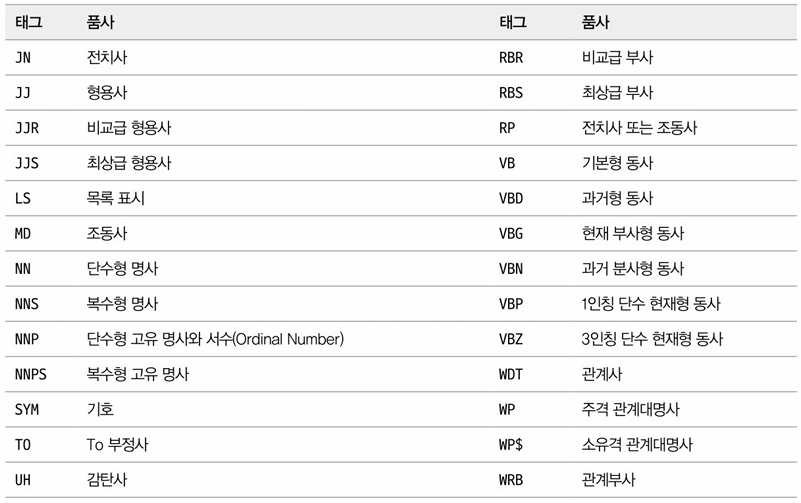

**spaCy**
* Cython 기반으로 개발된 오픈 소스 라이브러리
* 빠른 속도, 높은 정확도를 목표로하는 머신러닝 기반의 자연어 처리 라이브러리
* 24개 이상의 언어로 사전 학습된 모델 제공
* 객체 지향적으로 구현돼 처리한 결과를 doc 객체에 저장
* doc 객체는 다시 여러 token 객체로 이뤄져 있고 이 token 객체에 대한 정보를 기반으로 다양한 자연어 처리 작업 수행


In [12]:
!pip install spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 119.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


* token 객체에는
> 기본 품사 속성(pos_), 세분화 품사 속성(tag_), 원본 텍스트 데이터(text), 토큰 사이의 공백을 포함하는 텍스트 데이터(text_with_ws), 벡터(vector), 벡터 노름(vector_norm) 등의 속성 포함됨

In [13]:
import spacy

nlp = spacy.load("en_core_web_sm")
sentence = "Those who can imagein anything, can create the impossible."
doc = nlp(sentence) #doc 객체가 반환됨

for token in doc: #token 객채의 tag_나 pos_와 같은 속성에 접근해 값 확인
  print(f"[{token.pos_:5} - {token.tag_:3}] : {token.text}")

[PRON  - DT ] : Those
[PRON  - WP ] : who
[AUX   - MD ] : can
[VERB  - VB ] : imagein
[PRON  - NN ] : anything
[PUNCT - ,  ] : ,
[AUX   - MD ] : can
[VERB  - VB ] : create
[DET   - DT ] : the
[ADJ   - JJ ] : impossible
[PUNCT - .  ] : .


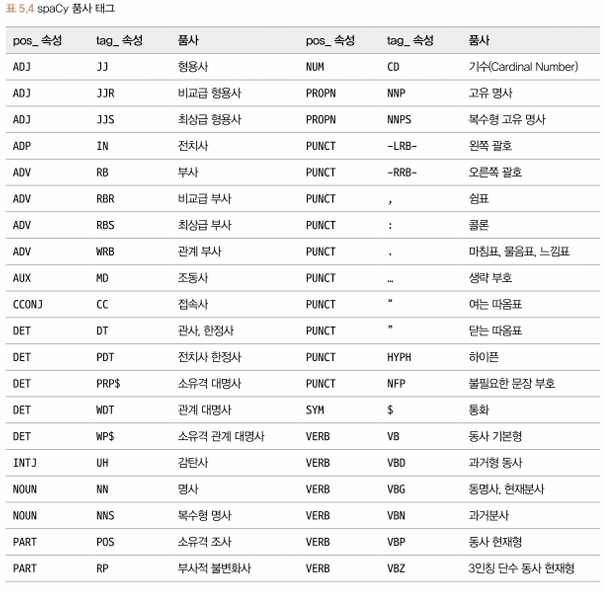

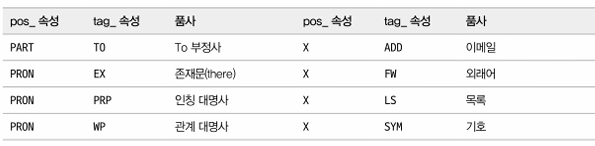

##하위 단어 토큰화

###바이트 페어 인코딩

**센텐스피스**
* 구글에서 개발한 오픈소스 하위 단어 토크나이저 라이브러리

**코포라 라이브러리**
* 국립국어원이나 AI Hub에서 제공하는 말뭉치 데이터를 쉽게 사용할 수 있게 제공하는 오픈소스 라이브러리

In [1]:
!pip install setencepiece

ERROR: Could not find a version that satisfies the requirement setencepiece (from versions: none)
ERROR: No matching distribution found for setencepiece


**Tokenizer 모델 학습**

In [2]:
!pip install Korpora
from Korpora import Korpora

corpus = Korpora.load("korean_petitions")
dataset = corpus.train
petition = dataset[0]

print("청원 시작인:", petition.begin)
print("청원 종료일:", petition.end)
print("청원 동의 수:", petition.num_agree)
print("청원 범주:", petition.category)
print("청원 제목:", petition.title)
print("청원 본문:", petition.text[:30])


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : Hyunjoong Kim lovit@github
    Repository : https://github.com/lovit/petitions_archive
    References :

    청와대 국민청원 게시판의 데이터를 월별로 수집한 것입니다.
    청원은 게시판에 글을 올린 뒤, 한달 간 청원이 진행됩니다.
    수집되는 데이터는 청원종료가 된 이후의 데이터이며, 청원 내 댓글은 수집되지 않습니다.
    단 청원의 동의 개수는 수집됩니다.
    자세한 내용은 위의 repository를 참고하세요.

    # License
    CC0 1.0 Universal (CC0 1.0) Public Domain Dedication
    Details in https://creativecommons.org/publicdomain/zero/1.0/

[Korpora] Corpus `korean_petitions` is already installed at /root/Korpora/korean_petitions/petitions_2017-08
[Korpora] Corpus `korean_petitions` is already installed at /root/Korpora/korean_petitions/petitions_2017-09
[Korpora] Corpus `korean_petitions` is already installed at /root/Korpora/kore

[korean_petitions] download petitions_2018-05: 37.5MB [00:00, 155MB/s]                            
[korean_petitions] download petitions_2018-06: 37.8MB [00:00, 131MB/s]                            
[korean_petitions] download petitions_2018-07: 40.5MB [00:00, 218MB/s]                            
[korean_petitions] download petitions_2018-08: 39.8MB [00:00, 125MB/s]                            
[korean_petitions] download petitions_2018-09: 36.1MB [00:00, 150MB/s]                            
[korean_petitions] download petitions_2018-10: 38.1MB [00:00, 137MB/s]                            
[korean_petitions] download petitions_2018-11: 37.7MB [00:00, 171MB/s]                            
[korean_petitions] download petitions_2018-12: 33.0MB [00:00, 203MB/s]                            
[korean_petitions] download petitions_2019-01: 34.8MB [00:00, 83.2MB/s]                            
[korean_petitions] download petitions_2019-02: 30.8MB [00:00, 160MB/s]                             
[korean_

청원 시작인: 2017-08-25
청원 종료일: 2017-09-24
청원 동의 수: 88
청원 범주: 육아/교육
청원 제목: 학교는 인력센터, 취업센터가 아닙니다. 정말 간곡히 부탁드립니다.
청원 본문: 안녕하세요. 현재 사대, 교대 등 교원양성학교들의 예비


In [5]:
from Korpora import Korpora
import os

# Create the directory if it doesn't exist
os.makedirs("../datasets", exist_ok=True)

corpus = Korpora.load("korean_petitions")
petitions = corpus.get_all_texts()
with open("../datasets/corpus.txt", "w", encoding = "utf-8") as f:
  for petition in petitions:
    f.write(petition + "\n")


    Korpora 는 다른 분들이 연구 목적으로 공유해주신 말뭉치들을
    손쉽게 다운로드, 사용할 수 있는 기능만을 제공합니다.

    말뭉치들을 공유해 주신 분들에게 감사드리며, 각 말뭉치 별 설명과 라이센스를 공유 드립니다.
    해당 말뭉치에 대해 자세히 알고 싶으신 분은 아래의 description 을 참고,
    해당 말뭉치를 연구/상용의 목적으로 이용하실 때에는 아래의 라이센스를 참고해 주시기 바랍니다.

    # Description
    Author : Hyunjoong Kim lovit@github
    Repository : https://github.com/lovit/petitions_archive
    References :

    청와대 국민청원 게시판의 데이터를 월별로 수집한 것입니다.
    청원은 게시판에 글을 올린 뒤, 한달 간 청원이 진행됩니다.
    수집되는 데이터는 청원종료가 된 이후의 데이터이며, 청원 내 댓글은 수집되지 않습니다.
    단 청원의 동의 개수는 수집됩니다.
    자세한 내용은 위의 repository를 참고하세요.

    # License
    CC0 1.0 Universal (CC0 1.0) Public Domain Dedication
    Details in https://creativecommons.org/publicdomain/zero/1.0/

[Korpora] Corpus `korean_petitions` is already installed at /root/Korpora/korean_petitions/petitions_2017-08
[Korpora] Corpus `korean_petitions` is already installed at /root/Korpora/korean_petitions/petitions_2017-09
[Korpora] Corpus `korean_petitions` is already installed at /root/Korpora/kore

In [7]:
from sentencepiece import SentencePieceTrainer

SentencePieceTrainer.Train(
    "--input=../datasets/corpus.txt --model_prefix=petition_bpe --vocab_size=8000 --model_type=bpe"
)

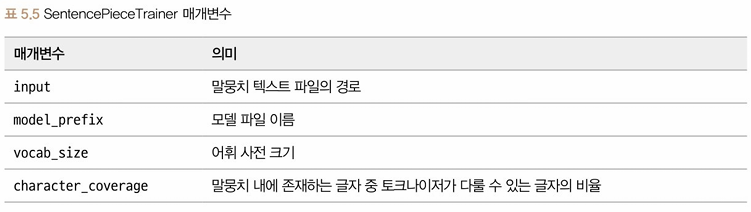

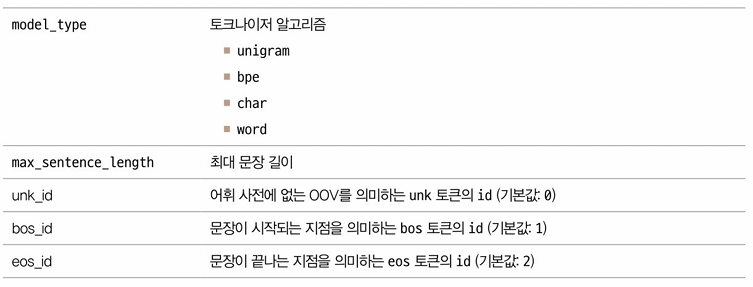

* 토크나이저 모델 학습이 완료되면 petition_bpe.model 파일과 petition_bpe.vocab 파일이 생성됨
* sentencepiece library는 띄어쓰기느 공백도 특수문자로 취급해 토큰화 과정에서 '_'로 공백을 표현

In [9]:
from sentencepiece import SentencePieceProcessor

tokenizer = SentencePieceProcessor()
tokenizer.load("petition_bpe.model")

sentence = "안녕하세요, 토크나이저가 잘 학습되었군요!"
sentences = ["이렇게 입력값을 리스트로 받아서", "쉽게 토크나이저를 사용할 수 있답니다"]

tokenized_sentence = tokenizer.encode_as_pieces(sentence)
tokenized_sentences = tokenizer.encode_as_pieces(sentences)
print("단일 문장 토큰화:", tokenized_sentence)
print("여러 문장 토큰화:", tokenized_sentences)

encoded_sentence = tokenizer.encode_as_ids(sentence) #토큰을 정수(토큰에 매핑된 ID 값)로 인코딩해 제공
encoded_sentences = tokenizer.encode_as_ids(sentences)
print("단일 문장 인코딩:", encoded_sentence)
print("여러 문장 정수 인코딩:", encoded_sentences)

decode_ids = tokenizer.decode_ids(encoded_sentences)
decode_pieces = tokenizer.decode_pieces(tokenized_sentences)
print("정수 인코딩에서 문장 변환:", decode_ids)
print("하위 단어 토큰에서 문장 변환:", decode_pieces)

단일 문장 토큰화: ['▁안녕하세요', ',', '▁토', '크', '나', '이', '저', '가', '▁잘', '▁학', '습', '되었', '군요', '!']
여러 문장 토큰화: [['▁이렇게', '▁입', '력', '값을', '▁리', '스트', '로', '▁받아서'], ['▁쉽게', '▁토', '크', '나', '이', '저', '를', '▁사용할', '▁수', '▁있', '답니다']]
단일 문장 인코딩: [667, 6553, 994, 6880, 6544, 6513, 6590, 6523, 161, 110, 6554, 872, 787, 6648]
여러 문장 정수 인코딩: [[372, 182, 6677, 4433, 1772, 1613, 6527, 4162], [1681, 994, 6880, 6544, 6513, 6590, 6536, 5852, 19, 5, 2639]]
정수 인코딩에서 문장 변환: ['이렇게 입력값을 리스트로 받아서', '쉽게 토크나이저를 사용할 수 있답니다']
하위 단어 토큰에서 문장 변환: ['이렇게 입력값을 리스트로 받아서', '쉽게 토크나이저를 사용할 수 있답니다']


In [10]:
from sentencepiece import SentencePieceProcessor

tokenizer = SentencePieceProcessor()
tokenizer.load("petition_bpe.model")

vocab = {idx: tokenizer.id_to_piece(idx) for idx in range(tokenizer.get_piece_size())}
print(list(vocab.items())[:5])
print("vocab size:", len(vocab))

[(0, '<unk>'), (1, '<s>'), (2, '</s>'), (3, '니다'), (4, '▁이')]
vocab size: 8000


* <unk> : OOV 발생 시 매핑됨
* \<s> 와 \</s>는 문장의 시작 지점과 종료 지점을 표시

**토크나이저스**
* Normalization와 pre-tokenization 제공
* Normalization: 불필요한 공백 제거, 대소문자 변환, 유니코드 정규화, 구두점 처리, 특수 문자 처리 등 제공
* 사전 토큰화: 공백 or 구두점을 기준으로 입력 문장을 나눠 텍스트 데이터를 효율적으로 처리하고 모델의 성능 향상

In [11]:
!pip install tokenizers

In [12]:
from tokenizers import Tokenizer
from tokenizers.models import WordPiece
from tokenizers.normalizers import Sequence, NFD, Lowercase
from tokenizers.pre_tokenizers import Whitespace

tokenizer = Tokenizer(WordPiece())
tokenizer.normalizer = Sequence([NFD(), Lowercase()]) #NFD(정구화), 소문자 변환(Lowercase)
tokenizer.pre_tokenizer = Whitespace()

tokenizer.train(["../datasets/corpus.txt"])
tokenizer.save("../models/petition_wordpiece.json")

Exception: No such file or directory (os error 2)

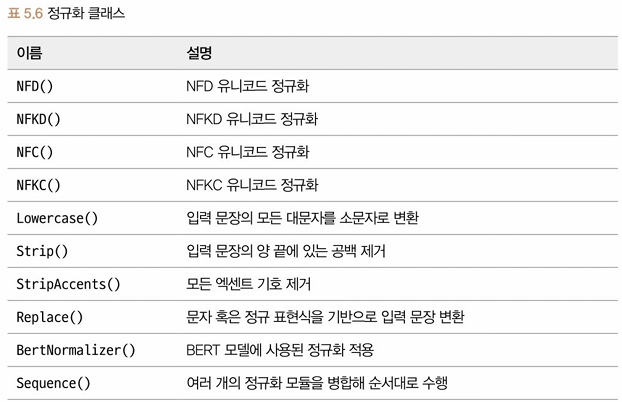

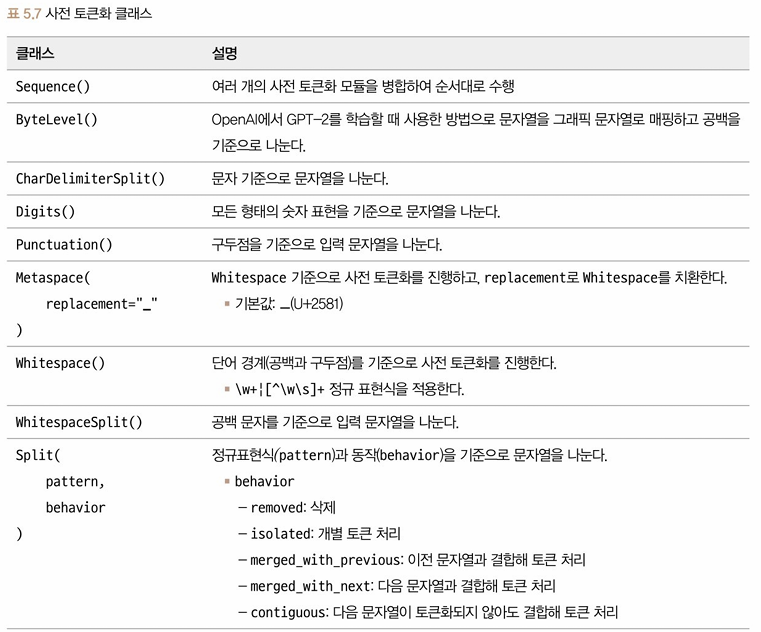

In [15]:
import os
from tokenizers import Tokenizer
from tokenizers.decoders import WordPiece as WordPieceDecoder
from tokenizers.models import WordPiece
from tokenizers.normalizers import Sequence, NFD, Lowercase
from tokenizers.pre_tokenizers import Whitespace

# Define a Colab-friendly path for the model file
model_path = "./models/petition_wordpiece.json" # This resolves to /content/models/petition_wordpiece.json

try:
    # Attempt to load the tokenizer from the correct path
    tokenizer = Tokenizer.from_file(model_path)
    print(f"Tokenizer loaded successfully from {model_path}")
except Exception as e: # Catch the file not found error and attempt to retrain
    print(f"Model file not found at {model_path}. Error: {e}. Attempting to re-train and save.")

    # Create the directory if it doesn't exist
    os.makedirs(os.path.dirname(model_path), exist_ok=True)

    # Re-train the tokenizer (assuming corpus.txt is available at ../datasets/corpus.txt)
    tokenizer = Tokenizer(WordPiece())
    tokenizer.normalizer = Sequence([NFD(), Lowercase()])
    tokenizer.pre_tokenizer = Whitespace()
    tokenizer.train(["../datasets/corpus.txt"])
    tokenizer.save(model_path)
    print(f"Tokenizer re-trained and saved to {model_path}.")
    # Load the newly saved tokenizer
    tokenizer = Tokenizer.from_file(model_path)

tokenizer.decoder = WordPieceDecoder()
sentence = "안녕하세요, 토크나이저가 잘 학습되었군요!"
sentences = ["이렇게 입력값을 리스트로 받아서", '쉽게 토크나이저를 사용할 수 있답니다']

encoded_sentence = tokenizer.encode(sentence)
encoded_sentences = tokenizer.encode_batch(sentences)

print("인코더 형식:", type(encoded_sentence))

print("단일 문장 토큰화:", encoded_sentence.tokens)
print("여러 문장 토큰화:", [enc.tokens for enc in encoded_sentences])

print("단일 문장 정수 인코딩:", encoded_sentence.ids)
print("여러 문장 정수 인코딩:", [enc.ids for enc in encoded_sentences])

print("정수 인코딩에서 문장 변환:", tokenizer.decode(encoded_sentence.ids))

Model file not found at ./models/petition_wordpiece.json. Error: No such file or directory (os error 2). Attempting to re-train and save.
Tokenizer re-trained and saved to ./models/petition_wordpiece.json.
인코더 형식: <class 'tokenizers.Encoding'>
단일 문장 토큰화: ['안녕하세요', ',', '토', '##크', '##나이', '##저', '##가', '잘', '학습', '##되었', '##군요', '!']
여러 문장 토큰화: [['이렇게', '입력', '##값을', '리스트', '##로', '받아서'], ['쉽게', '토', '##크', '##나이', '##저', '##를', '사용할', '수', '있다', '##ᆸ니다']]
단일 문장 정수 인코딩: [8760, 11, 8693, 8415, 16269, 7536, 7488, 7842, 15016, 8670, 8734, 0]
여러 문장 정수 인코딩: [[8187, 19643, 13834, 28119, 7495, 12607], [9739, 8693, 8415, 16269, 7536, 7510, 14129, 7562, 8157, 7489]]
정수 인코딩에서 문장 변환: 안녕하세요, 토크나이저가 잘 학습되었군요!


#6장. 인코딩

###N-gram
* 작은 규모의 데이터세트에서 연속된 문자열 패턴을 분석하는데 큰 효과를 보임. 관용적 표현 분석에도 활용


In [16]:
import nltk

def ngrams(sentence, n):
  words = sentence.split()
  ngrams = zip(*[words[i:] for i in range(n)])
  return list(ngrams)

sentence = "안녕하세요 만나서 진심으로 반가워요"

unigram = ngrams(sentence, 1)
bigram = ngrams(sentence, 2)
trigram = ngrams(sentence, 3)

print(unigram)
print(bigram)
print(trigram)

unigram = nltk.ngrams(sentence.split(), 1)
bigram = nltk.ngrams(sentence.split(),2)
trigram = nltk.ngrams(sentence.split(),3)

print(list(unigram))
print(list(bigram))
print(list(trigram))

[('안녕하세요',), ('만나서',), ('진심으로',), ('반가워요',)]
[('안녕하세요', '만나서'), ('만나서', '진심으로'), ('진심으로', '반가워요')]
[('안녕하세요', '만나서', '진심으로'), ('만나서', '진심으로', '반가워요')]
[('안녕하세요',), ('만나서',), ('진심으로',), ('반가워요',)]
[('안녕하세요', '만나서'), ('만나서', '진심으로'), ('진심으로', '반가워요')]
[('안녕하세요', '만나서', '진심으로'), ('만나서', '진심으로', '반가워요')]


###TF-IDF

In [17]:
!pip install scikit-learn

In [21]:
import sklearn
tfidf_vectorizer = sklearn.feature_extraction.text.TfidfVectorizer(
    input = "content",
    encoding = "utf-8", #byte 혹은 file을 입력값으로 받을 경우 사용할 텍스트 인코딩 값
    lowercase = True, # 입력받은 데이터를 소문자로 변환할지 여부
    stop_words = None, #분석에 도움X 단어
    ngram_range = (1,1), #N-gram 범위=> (min, max)
    max_df = 1.0, #전체 문서 중 일정 횟수 이상 등장한 단어는 불용어로 처리. 정수 입력시-> 횟수로 계산, 1이하 실수 입력시, 비율로 계산
    min_df = 1, #전체 문서 중 일정 횟수 미만으로 등장한 단어를 불용어 처리
    vocabulary = None,
    smooth_idf = True, #분모에 1 더함
)

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

corpus = [
    "That movie is famous movie",
    "I like that actor",
    "I don't like that actor"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_vectorizer.fit(corpus) #corpus 학습
tfidf_matrix = tfidf_vectorizer.transform(corpus) #데이터 변환 수행

print(tfidf_matrix.toarray()) #TF-IDF를 넘파이 배열로 변환, (문서수)*(단어수)
print(tfidf_vectorizer.vocabulary_) #TF-IDF에 사용된 단어 사전. 키는 고유한 단어, 값은 단어에 대한 색인 값

[[0.         0.         0.39687454 0.39687454 0.         0.79374908
  0.2344005 ]
 [0.61980538 0.         0.         0.         0.61980538 0.
  0.48133417]
 [0.4804584  0.63174505 0.         0.         0.4804584  0.
  0.37311881]]
{'that': 6, 'movie': 5, 'is': 3, 'famous': 2, 'like': 4, 'actor': 0, 'don': 1}
